In [1]:
import os
import s3fs
import pandas as pd
import sklearn

In [3]:
print(pd.__version__)
sklearn.__version__

2.3.3


'1.8.0'

In [4]:
# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

In [8]:
# fs.ls("donnees-insee/diffusion")

In [10]:
BUCKET = "1020cepe01"
FILE_KEY_S3 = "data/readmission_avc.parquet"
FILE_PATH_S3 = BUCKET + "/" + FILE_KEY_S3
FILE_PATH_S3

'1020cepe01/data/readmission_avc.parquet'

In [11]:
with fs.open(FILE_PATH_S3, mode="rb") as file_in:
    dataini = pd.read_parquet(file_in)

In [9]:
# dataini = pd.read_parquet('data/readmission_avc.parquet')
# dataini

,modeEntree,modeSortie,duree,ghm2,dp,sexe,age,nbActe,nbRum,nbda,id,id_D
0,8,9,0,01M37E,I671,2.0,76.0,4,1,NaN,l19,
1,8,8,3,01C061,I652,2.0,77.0,4,1,1.0,s7e,
2,8,7,13,01M303,I634,NaN,NaN,4,1,7.0,23f,
3,8,8,11,01M301,I639,1.0,83.0,4,2,2.0,8oi,None
4,8,6,8,01M303,I635,1.0,71.0,4,1,9.0,otz,ld
...,...,...,...,...,...,...,...,...,...,...,...,...
1695,8,7,1,01M30T,I614,1.0,88.0,4,1,4.0,kjg,
1696,8,6,10,01M303,I635,1.0,81.0,10,3,7.0,gie,my
1697,8,8,8,01M301,I639,1.0,68.0,5,3,6.0,6bl,
1698,8,8,11,01M301,I676,2.0,28.0,16,5,7.0,7m8,


# 1. Data Preprocessing

In [ ]:
dataini.isna().sum()

### 1.1 Encoding Label 

In [ ]:
dataini["rea"] = (dataini["id_D"] != "").astype("int8") # int8 → 1 octet par valeur
# convertir en boolean

In [ ]:
dataini = dataini.dropna(subset=['id_D'], axis= 0).copy()

# subset est obligatoire

In [ ]:
dataini

In [ ]:
dataini.rea.value_counts()

In [ ]:
dataini.dtypes

### 1.2 Categorical variables 

In [ ]:
str_cols = ['modeEntree', 'modeSortie', 'sexe']


In [ ]:
# contre exemple
# dataini[str_cols] = dataini[str_cols].astype('str')

In [ ]:
dataini[str_cols] = dataini[str_cols].astype("object")

In [ ]:
dataini.isna().sum()

### 1.3 nbda : faux manquant

In [ ]:
dataini.nbda.value_counts()

In [ ]:
dataini['nbda'] = dataini['nbda'].fillna(0)

In [ ]:
dataset = dataini[dataini.modeSortie != '9'].drop(['id', 'id_D'], axis =1)

In [ ]:
# dataset.to_parquet('data/dataset.parquet')

# 2. Feature engineering

## 2.1 Principes

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer

In [ ]:
dataset[['sexe']]

In [ ]:
SimpleImputer(strategy='most_frequent').fit_transform(dataset[['sexe']])

In [ ]:
OneHotEncoder(drop = 'first', sparse_output= False).fit_transform(SimpleImputer(strategy='most_frequent').fit_transform(dataset[['modeEntree', 'modeSortie', 'sexe']]))

In [ ]:
dataset[['modeEntree', 'modeSortie', 'sexe']]

## 2.2 Preprocessing Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer # permettant d'appliquer les pipelines simultanément
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

In [ ]:
features = dataset.drop('rea', axis = 1)
label = dataset['rea']

In [ ]:
features.dtypes

In [ ]:
num_features = dataset.select_dtypes(include= ['int32', 'float64']).columns.tolist()
num_features = dataset.select_dtypes(include= ['int32', 'float64']).columns
num_features

In [ ]:
cat_features = dataset.select_dtypes(include= ['object']).columns
cat_features

In [ ]:
num_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer()),
    ('scaler', MinMaxScaler())
])

In [ ]:
cat_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy= 'most_frequent')),
    # ('ohe', OneHotEncoder()), # par defaut error
    ('ohe', OneHotEncoder(handle_unknown= 'ignore'))
    # ('ohe', OneHotEncoder(handle_unknown= 'infrequent_if_exist')) # encodée comme “catégorie rare” si (et seulement si) une catégorie infrequent existe déjà
])

In [ ]:
preprocessor = ColumnTransformer(transformers= [
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

In [ ]:
preprocessor.fit_transform(features).toarray().shape

In [ ]:
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(features, label, test_size= 0.1, random_state= 18)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size= 0.2, random_state= 42)

In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

# 3. Models

## 3.1 logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
pip_reg = Pipeline(steps=[
    ('preproc', preprocessor),
    ('classifier', LogisticRegression(max_iter= 4000))
])

In [ ]:
pip_reg_fitted = pip_reg.fit(X_train, y_train)

In [ ]:
y_predict = pip_reg_fitted.predict(X_val)
y_predict_proba = pip_reg_fitted.predict_proba(X_val)[:,1]

* Première colonne : La probabilité que chaque observation appartienne à la classe négative (𝑦 = 0). 
* Deuxième colonne : La probabilité que chaque observation appartienne à la classe positive (𝑦 = 1).

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

In [ ]:
accuracy_score(y_val, y_predict)

In [ ]:
f1_score(y_val, y_predict)

In [ ]:
roc_auc_score(y_val, y_predict_proba)

## 3.1 (suite) Penalised logistic regression

#### Regression lineaire non penalisee (OLS)

- modele simple
- biais eleve
- variance faible
- sur-apprentissage faible

#### Regression penalisee avec regularisation faible (alpha faible)

- tres proche de OLS
- biais legerement plus eleve que OLS
- variance legerement plus faible que OLS
- comportement global tres similaire a OLS
- sur-apprentissage faible

#### Regression penalisee avec regularisation forte (alpha fort)

- coefficients fortement contraints
- biais nettement plus eleve que OLS
- variance nettement plus faible que OLS
- modele tres stable
- sur-apprentissage quasi nul


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
metric_grid = ['accuracy', 'f1', 'roc_auc']

In [ ]:
lr = LogisticRegression(max_iter= 4000, tol=1e-3) # par défaut 1e-4

# tol = le seuil à partir duquel le modèle considère qu’il ne progresse plus vraiment.

# Le solveur saga est une méthode d'optimisation basée sur la descente de gradient stochastique (Stochastic Average Gradient), 
# qui utilise des mini-batchs (sous-échantillons) aléatoires des données pour optimiser les poids.
# est le seul à supporter ElasticNet dans LogisticRegression

# max_iter = 500 défaut : Les solveurs comme lbfgs (par défaut) ou saga n'ajustent pas les coefficients en une seule étape. Ils calculent les gradients et mettent à jour les poids de manière itérative.

In [ ]:
pip_lr = Pipeline(steps=[
    ('preproc', preprocessor),
    ('classifier', lr)
])

In [ ]:
# ne converge pas quand on passe à autre FE

param_lr = [
    # Ridge
    {
        'classifier__l1_ratio': [0],
        'classifier__C': [10, 100, 1000],
        'classifier__solver': ['lbfgs']
    },

    # Lasso
    {
        'classifier__l1_ratio': [1],
        'classifier__C': [10, 100, 1000],
        'classifier__solver': ['saga']
    },

    # Elastic Net
    {
        'classifier__l1_ratio': [0.1, 0.5, 0.9],
        'classifier__C': [10, 100, 1000],
        'classifier__solver': ['saga']
    }
]


* C = intensité de la pénalité. C est l'inverse de la force de régularisation (𝐶=1/𝜆)
* penalty = type de régularisation (L1, L2, ou ElasticNet).
* l1_ratio = coefficient pour ElasticNet, spécifiant le compromis entre L1 et L2.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
grid_lr = GridSearchCV(
            estimator= pip_lr, 
            param_grid= param_lr,
            cv = cv,
            scoring=metric_grid,
    refit = 'roc_auc'
)

In [ ]:
grid_lr_fitted = grid_lr.fit(X_train_val, y_train_val)

In [ ]:
grid_lr_fitted.best_params_ # lasso

In [ ]:
grid_lr_fitted.score(X_test, y_test)

## 3.2 RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from pprint import pprint

Cas où fixer le random_state est important :

Comparaison entre modèles Lorsque vous comparez plusieurs modèles (par exemple, RandomForest, Gradient Boosting, SVM, etc.), il est recommandé de fixer le random_state dans les modèles aléatoires comme RandomForest ou Gradient Boosting.
Cela garantit que les scores de validation croisée des modèles aléatoires ne fluctuent pas inutilement, et les comparaisons sont basées uniquement sur leurs performances réelles, et non sur des différences dues au hasard.

In [ ]:
rf = RandomForestClassifier(random_state= 42) ## 

In [ ]:
pip_rf = Pipeline(steps= [
    ("preproc", preprocessor),
    ("classifier", rf)
])

In [ ]:
pprint(RandomForestClassifier().get_params())

In [ ]:
param_rf = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [10, 20, None],
    # 'classifier__min_samples_split': [2, 5, 10], # defaut = 2, nombre minimum d’échantillons requis dans un nœud pour qu’on ait le droit de le splitter
    # 'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

**n_estimators** (Nombre d'arbres dans la forêt)<br/>

Pourquoi le tuner ?<br/>
* Augmenter le nombre d'arbres améliore souvent la performance du modèle (réduit la variance), mais au prix d'une augmentation du temps d'entraînement et d'inférence.
* Par défaut, 100 arbres suffisent souvent, mais augmenter à 200 ou 500 peut être utile pour des datasets complexes.
* Valeurs courantes : 50, 100, 200, 500.


**max_depth** (Profondeur maximale des arbres)<br/>
Description : Contrôle la profondeur maximale de chaque arbre.

Pourquoi le tuner ?<br/>
* Limiter la profondeur aide à éviter le surapprentissage (overfitting).
* Des arbres très profonds capturent trop de bruit (spécificité du dataset d'entrainement) dans les données, tandis que des arbres peu profonds risquent de sous-apprendre (underfitting).

Valeurs courantes :<br/>
* None (par défaut, arbre entièrement développé).
* Valeurs typiques : 5, 10, 20, en fonction de la taille des données.


**max_features** (nombre de variables candidates examinées à chaque split)<br/>
Description : Nombre de features à échantillonner aléatoirement pour rechercher la meilleure division à chaque split.<br/>
* 'sqrt' : 
* 'log2' : 
* Un entier : Un nombre fixe de features.<br/>

Pourquoi le tuner ?
* Moins de features à chaque split réduit la corrélation entre les arbres, ce qui améliore la diversité de la forêt.
* Trop peu de features peuvent limiter la capacité d'apprentissage des arbres.
* Valeurs courantes : 'sqrt', 'log2', 0.3, 0.5 (fraction des features).

**min_samples_leaf** (Nombre mininum d’échantillons par feuille)<br/>
Description : Nombre mininum d'échantillons requis pour qu'un nœud soit une feuille (Le nombre minimum d'individus (ou de lignes) requis pour qu’un nœud soit considéré comme une feuille.).<br/>
Pourquoi le tuner ?<br/>
* Augmenter cette valeur force les feuilles à contenir plus d’échantillons, ce qui réduit le surapprentissage.<br/>
* Cela est particulièrement utile pour les datasets déséquilibrés (explication dans la cellule suivante "Probabilité prédite dans une feuille d’arbre de décision") ou bruités.<br/>

Valeurs courantes : 1 (par défaut), 5, 10, 20.

**min_samples_split** :
  - Rôle : nombre minimum d'échantillons requis dans un nœud pour qu'il puisse être divisé.
  - Valeur par défaut (scikit-learn) : `2`.
  - Peut être :
    - un `int` : nombre d'échantillons (ex. `min_samples_split=20`),
    - un `float` entre 0 et 1 : proportion de l'échantillon total (ex. `min_samples_split=0.05` = au moins 5 % des données dans le nœud).


In [ ]:
metric_grid = ['accuracy', 'f1', 'roc_auc']

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold garantit que chaque fold respecte la proportion de classes, mais il respecte aussi l’ordre des données si shuffle=False.

In [ ]:
grid_rf = GridSearchCV(
    estimator= pip_rf,
    param_grid= param_rf,
    cv=cv,
    scoring='accuracy',
    refit= True, 
    error_score='raise'   # <-- LA CLE
)

# le cas de multi metric, il faut obligatoirement renseigner le 
grid_rf = GridSearchCV(
            estimator=pip_rf, 
            cv = cv,
            scoring= metric_grid,
            refit= 'roc_auc',
            param_grid= param_rf
) 

In [ ]:
grid_rf_fitted = grid_rf.fit(X_train_val, y_train_val)

### Probabilité prédite dans une feuille d’arbre de décision

Pour un arbre de classification, la prédiction dans une feuille est, en première approximation, la proportion d’observations positives dans cette feuille :

$$
\hat{p} = \frac{n_{pos}}{n_{total}}
$$

où :

- $$n_{pos}$$ est le nombre d’observations positives dans la feuille,
- $$n_{total}$$ est le nombre total d’observations dans la feuille.

Conséquences importantes :

- Si une feuille contient **1 seule observation** et qu’elle est positive, on obtient :

  $$
  \hat{p} = 1.0
  $$

  c’est-à-dire « 100 % de chances d’être positif ».

- Cette probabilité est basée sur **un seul individu** : le moindre bruit, une erreur de label ou un cas très atypique peut complètement changer la prédiction.

- Des feuilles avec très peu d’observations donnent donc des **probabilités très instables** et favorisent le **sur-apprentissage** (le modèle colle à des cas particuliers plutôt qu’à des tendances générales).


In [ ]:
grid_rf_fitted.cv_results_.keys()

In [ ]:
grid_rf_fitted.best_params_

In [ ]:
grid_rf_fitted.best_score_

In [ ]:
grid_rf_fitted.score(X_test, y_test)

grid_rf_fitted est best_estimator_ refit selon toute les données de cv

In [ ]:
# equivalent à
roc_auc_score(y_test, grid_rf_fitted.predict_proba(X_test)[:,1])

#### `GridSearchCV` et `refit=True`

Avec `refit=True`, `GridSearchCV` :
- selectionne les meilleurs hyperparametres par validation croisee
- puis **re-entraine un modele unique** sur **toutes les donnees passees a `.fit()`**

Le modele final correspond a : grid_rf_fitted.best_estimator_


Il est **refitte avec les meilleurs hyperparametres**, sur **l’ensemble des donnees d’entrainement**.

In [ ]:
# equivalent à 
grid_lr_refitted = grid_lr_fitted.best_estimator_.fit(X_train_val, y_train_val)
roc_auc_score(y_test, grid_lr_refitted.predict_proba(X_test)[:,1])

## 3.3 KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
pprint(KNeighborsClassifier().get_params())

#### Hyperparamètres courants à tuner pour KNN<br/>

**n_neighbors** (Nombre de voisins)<br/>
Description : Définit combien de voisins sont considérés pour prendre une décision.<br/>
Pourquoi le tuner ?<br/>
* Un nombre de voisins trop faible peut rendre le modèle sensible au bruit (overfitting).
* Un nombre trop élevé peut le rendre trop généralisant (underfitting).
<br/>Valeurs courantes : 3, 5, 7, 10, 15.

**weights** (Pondération des voisins)
Description : Définit si tous les voisins contribuent également ou si leur contribution est pondérée par la distance.
'uniform' : Tous les voisins ont le même poids.
'distance' : Les voisins proches ont plus de poids que les voisins éloignés.
Pourquoi le tuner ? <br/>
La pondération par distance peut améliorer la performance si les observations proches sont plus représentatives de la classe cible.
Valeurs courantes : 'uniform', 'distance'.


**metric** (Distance utilisée pour trouver les voisins)
Description : Définit la mesure de distance utilisée pour calculer la proximité entre les points.
* 'minkowski' : Distance généralisée.
* 'euclidean' : Distance euclidienne
* 'manhattan' : Distance Manhattan

Pourquoi le tuner ?<br/>
Certaines mesures de distance peuvent mieux capturer la structure des données en fonction du problème.
Valeurs courantes : 'euclidean', 'manhattan', 'minkowski'.

**p** (Paramètre pour la distance de Minkowski)
Description : Définit la puissance pour la distance de Minkowski.
* p=1 correspond à la distance Manhattan.
* p=2 correspond à la distance Euclidienne.
  
<br/>Pourquoi le tuner ?<br/>
* Ajuster la valeur de p permet d'explorer différents types de relations dans les données.
* Valeurs courantes : 1, 2, 3.


**algorithm** (Algorithme utilisé pour la recherche des voisins)
Description : Définit la méthode utilisée pour rechercher les voisins les plus proches.
- 'auto' : Choisit automatiquement l'algorithme le plus adapté.
- 'ball_tree' : Utilise une structure BallTree.
- 'kd_tree' : Utilise une structure KDTree.
- 'brute' : Recherche brute.
  
Pourquoi le tuner ?<br/>
Bien que 'auto' fonctionne dans la plupart des cas, certaines structures (comme kd_tree) peuvent être plus rapides pour des données spécifiques.



In [ ]:
knn = KNeighborsClassifier() 

In [ ]:
pip_knn = Pipeline(steps= [
    ('preproc', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [ ]:
from sklearn.preprocessing import MinMaxScaler, Normalizer

In [ ]:
param_knn = {
    'preproc__num__scaler': [
        StandardScaler(),
        MinMaxScaler()
    ],
    'classifier__n_neighbors': [3, 5, 7],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['minkowski'],
    'classifier__p': [1, 2]  # 1 = Manhattan, 2 = Euclidienne
}

# Distance euclidienne
# k = 7 pour l'intervalle 5 à 15, (compromis biais / variance raisonnable)
# pondération par la distance (les voisins proches comptent plus)
# StandardScaler (géométrie “classique”)
# C’est une solution très saine, très “baseline robuste”.

# 2nd temps, selon le resulat de 1er CV, juste changer le nb d'estimators
param_knn = {
    'preproc__num__scaler': [
        StandardScaler(),
        MinMaxScaler()
    ],
    'classifier__n_neighbors': [5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['minkowski'],
    'classifier__p': [1, 2]  # 1 = Manhattan, 2 = Euclidienne
}

In [ ]:
grid_knn = GridSearchCV(
            estimator=pip_knn,
            param_grid= param_knn,
            cv = 3,
            scoring= metric_grid,
            refit='roc_auc'
)

In [ ]:
grid_knn_fitted = grid_knn.fit(X_train_val, y_train_val)

In [ ]:
grid_knn_fitted.best_params_

In [ ]:
grid_knn_fitted.best_estimator_

In [ ]:
grid_knn_fitted.score(X_test, y_test)

In [ ]:
roc_auc_score(y_test, grid_knn_fitted.predict_proba(X_test)[:,1])

## 3.4 Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
pprint(GradientBoostingClassifier().get_params())

**learning_rate** <br/>
Description : Le Gradient Boosting construit les arbres séquentiellement : chaque nouvel arbre est formé pour corriger les erreurs faites par les arbres précédents. À chaque étape, le nouvel arbre ajuste les résidus (erreurs) des prédictions précédentes.Le learning_rate contrôle la contribution de chaque nouvel arbre à la prédiction globale 𝐹 𝑡 ( 𝑥 )<br/>
Importance : Très élevé.<br/>
* Un taux d'apprentissage faible (ex. : 0.01) nécessite plus d'arbres (n_estimators) pour atteindre des performances optimales.
* Un taux élevé (ex. : 0.2 ou 0.3) permet une convergence rapide, mais risque de sur-apprendre (pourquoi ? plus bas)
* Valeur par défaut : 0.1.
* Valeurs courantes : [0.01, 0.05, 0.1, 0.2].

Avec un nombre d’arbres raisonnable (c’est-à-dire un nombre raisonnable d’itérations de correction), un `learning_rate` élevé fait que chaque nouvel arbre réduit fortement l’erreur sur le jeu d’entraînement. Le modèle colle donc rapidement aux données d’apprentissage, ce qui augmente le risque de voir la perte sur le jeu de validation remonter plus tôt (sur-apprentissage).




**n_estimators**<br/>
Description : Nombre total d'arbres dans le modèle. A chaque itération, un seul arbre est ajouté au modèle<br/>
Importance : Très élevé.
* Un nombre insuffisant d'arbres peut sous-apprendre, tandis qu'un nombre trop élevé peut augmenter le temps d'entraînement sans amélioration significative.
* Valeur par défaut : 100.
* Valeurs courantes : [100, 200, 500, 1000], dépendant de la taille des données et de learning_rate.

**max_depth**<br/>
Description : Profondeur maximale de chaque arbre.<br/>
Importance : Élevée.
* Limiter la profondeur empêche les arbres de surapprendre en capturant trop de bruit.
* Une profondeur trop faible peut sous-apprendre les relations complexes dans les données.
* Valeur par défaut : 3.
* Valeurs courantes : [3, 5, 7, None].

**min_samples_split**<br/>
Description : Nombre mininum d'échantillons requis pour diviser un nœud.<br/>
Importance : Moyen.<br/>
* Permet de contrôler la taille minimale des nœuds parents, ce qui limite les arbres très complexes.
* Valeur par défaut : 2.
* Valeurs courantes : [2, 5, 10].

**min_samples_leaf** <br/>
Description : Nombre mininum d'échantillons requis pour être dans une feuille.<br/>
Importance : Moyen.<br/>
* Empêche les arbres de créer des feuilles contenant un très petit nombre de données, ce qui peut les rendre sensibles au bruit.
* Valeur par défaut : 1.
* Valeurs courantes : [1, 5, 10, 20].

Deux familles d’hyperparamètres en Gradient Boosting

En Gradient Boosting (type `GradientBoostingClassifier`, `XGBoost`, `LightGBM`…), on distingue deux grandes familles d’hyperparamètres.

#### 1) Hyperparamètres des arbres (forme des *weak learners*)

Ces hyperparamètres contrôlent la **complexité de chaque arbre** :

- `max_depth`
- `max_leaf_nodes`
- `min_samples_leaf`
- `min_samples_split`
- `max_features`
- `subsample`, etc.

Ils déterminent à quel point **un arbre individuel** peut s’adapter aux données : profondeur, nombre de feuilles, taille minimale des feuilles, nombre de variables testées par split, etc.

#### 2) Hyperparamètres du boosting

Ces hyperparamètres contrôlent **comment les arbres sont combinés au fil des itérations** :

- `learning_rate`
- `n_estimators`
- parfois `subsample` (dans certains algorithmes, pour faire du *stochastic gradient boosting*).

Ils déterminent la **dynamique de l’accumulation** des corrections :

- `learning_rate` : intensité de chaque correction apportée par un nouvel arbre ;
- `n_estimators` : nombre total d’itérations (nombre d’arbres).

---

On peut résumer ainsi :

- Les hyperparamètres des **arbres** contrôlent la **puissance de chaque correction** (capacité de chaque modèle élémentaire).
- `learning_rate` et `n_estimators` contrôlent la **façon dont ces corrections sont accumulées** (vitesse et finesse de l’apprentissage global).


In [ ]:
gb = GradientBoostingClassifier(random_state= 42)

pip_gb = Pipeline(steps=[
    ('preproc', preprocessor),
    ('classifier', gb)
    
])

param_gb = {
    'classifier__n_estimators' : [100, 200, 400],
    'classifier__learning_rate' :  [0.05, 0.1, 0.2],
    'classifier__max_depth' : [3, 5, 7],
    'classifier__max_features' : ['sqrt', 0.5, None], 
    'classifier__subsample': [0.8, 1.0] # Chaque arbre ne voit qu’une partie des donnees, ce qui evite que tous les arbres fassent exactement la meme chose.
}



grid_gb = GridSearchCV(estimator= pip_gb, 
                       param_grid= param_gb, 
                       scoring= metric_grid, 
                       cv = cv, refit = 'roc_auc')

grid_gb_fitted = grid_gb.fit(X_train_val, y_train_val)

grid_gb_fitted.best_estimator_

grid_gb_fitted.best_params_

grid_gb_fitted.score(X_test, y_test)

In [ ]:
# {'classifier__learning_rate': 0.2,
#  'classifier__max_depth': 7,
#  'classifier__max_features': 'sqrt',
#  'classifier__n_estimators': 100,
#  'classifier__subsample': 0.8}

In [ ]:
param_gb = {
    'classifier__learning_rate': [0.15, 0.2, 0.25],
    'classifier__n_estimators': [80, 100, 150],
    'classifier__max_depth': [5, 7, 9]
}

## 3.5 Multi-layer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
mlp = MLPClassifier(max_iter=2000, random_state=42)
# random_state controle l’initialisation aleatoire : 
# des poids des biais et aussi l’ordre des donnees lors de l’entrainement

In [ ]:
pip_mlp = Pipeline(steps= [
    ('preproc', preprocessor),
    ('classifier', mlp) #max_iter=1000, peut-être ajouter plus tard
])

In [ ]:
param_mlp = {
    # Architecture : on commence simple
    'classifier__hidden_layer_sizes': [
        (50,), (100,),
        (50, 50)
    ],

    # Activation des couches cachees
    'classifier__activation': ['relu', 'tanh'],

    # Solver stable par defaut
    'classifier__solver': ['adam'],

    # Regularisation L2
    'classifier__alpha': [1e-4, 1e-3, 1e-2],

    # Strategie du learning rate
    'classifier__learning_rate': ['constant', 'adaptive'],

    # Valeur initiale du learning rate (le vrai LR)
    'classifier__learning_rate_init': [1e-4, 1e-3]
}


In [ ]:
# selon le premier tuning si on peux retuning 
param_mlp = {
    'classifier__hidden_layer_sizes': [
        (50,), 
        # (100,),      # 1 couche cachée, mais 100 trop complexe par rapport dataset size
        # (50, 50), 
        # (100, 100)  # 2 couches cachées, mais 100 trop complexe par rapport dataset size
    ],
    'classifier__activation': ['tanh', 'relu'],
    # 'classifier__solver': ['sgd', 'adam'],
    'classifier__alpha': [0.0001],
    'classifier__learning_rate': ['adaptive'],
}

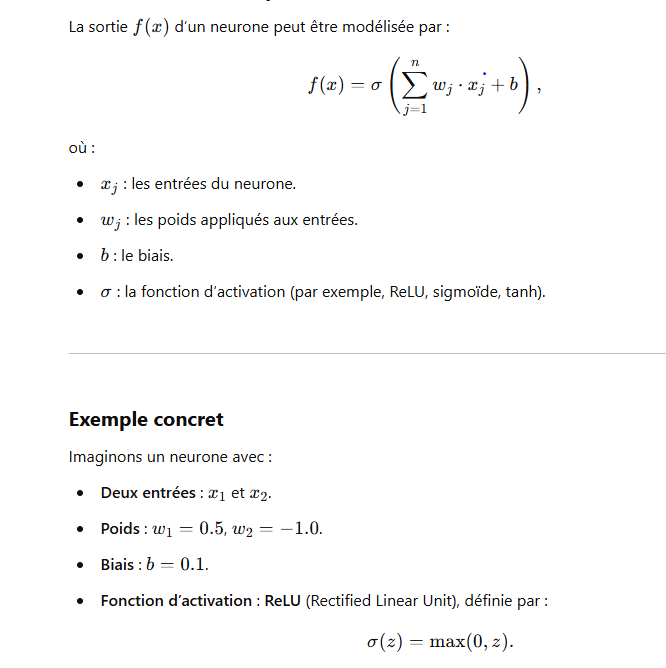

### 1. Un neurone ≈ une régression linéaire + une non-linéarité

Un neurone classique (dans un MLP) effectue 2 étapes :

1. **Combinaison linéaire des entrées** (comme une régression linéaire) :

$$
z = w_1 x_1 + w_2 x_2 + \dots + w_d x_d + b
$$

2. **Application d'une fonction d'activation** sur ce résultat :

$$
a = \sigma(z)
$$

Les poids $w_i$ et le biais $b$ correspondent à la partie "régression linéaire".  
La fonction $\sigma$ (ReLU, sigmoid, tanh, etc.) apporte la non-linéarité.

En résumé :

**Chaque neurone est une petite régression linéaire suivie d'une fonction d'activation non linéaire.**


**1. Structure du réseau** (architecture)<br/>
hidden_layer_sizes : Détermine le nombre de couches cachées et de neurones par couche.
* (50,) : Une seule couche cachée avec 50 neurones.
* (100,) : Une seule couche cachée avec 100 neurones.
* (50, 50) : Deux couches cachées, chacune avec 50 neurones.
* (100, 50) : Deux couches cachées, la première avec 100 neurones et la deuxième avec 50 neurones.

Pourquoi le tuner ?<br/>
* Une architecture simple avec peu de neurones (par exemple, (50,)) est plus rapide à entraîner mais peut manquer de capacité d'apprentissage.
* Une architecture plus complexe (par exemple, (100, 50)) peut mieux capturer des relations complexes dans les données, mais elle est plus susceptible de surapprendre sur de petits ensembles de données.

**activation**<br/> des couches cachés (on ne tune pas les fonctions d'activation de couche de sortie car cela dépend de problématique et choisi automatiquement par model => regarde dans la cellule suivante choix de fonctin d'activation)
* 'tanh' : Fonction tangente hyperbolique, produit des sorties dans la plage [-1, 1]. Elle peut bien capturer des relations complexes dans les données, surtout avec des distributions centrées autour de zéro.
* 'relu' (Rectified Linear Unit) : Produit des sorties dans la plage [0, ∞). Elle est efficace pour les réseaux profonds car elle aide à éviter le problème de gradient évanescent.
Pourquoi le tuner ?
'relu' est généralement plus rapide à entraîner et performant pour la plupart des tâches, mais 'tanh' peut être utile pour des problèmes où les relations non linéaires sont plus complexes.

**solver**<br/>
Le solver, c’est l’algorithme d’optimisation qu’on utilise pour apprendre les poids donc c'est nécessaire pour la régression. Pas spécifique a MLP.
* 'sgd' (Stochastic Gradient Descent) : Une méthode simple et flexible qui peut être plus lente à converger, mais est efficace avec un bon réglage des hyperparamètres comme le taux d'apprentissage.
* 'adam' (Adaptive Moment Estimation) : Un algorithme avancé et souvent plus rapide. Il ajuste dynamiquement le taux d'apprentissage en fonction des moments des gradients.
Pourquoi le tuner ?
* 'adam' est généralement performant pour de nombreux problèmes. 'sgd' peut être plus robuste dans certains cas, mais nécessite souvent un réglage fin du taux d'apprentissage.


**alpha**<br/>

alpha est le coefficient de regularisation L2 applique aux poids du MLP.
Il penalise les poids eleves dans la fonction de perte afin de limiter
le surapprentissage, de maniere analogue au parametre lambda
dans une regression ridge.



**learning_rate**<br/>
* Contrôle comment le modèle ajuste les poids à chaque itération d'entraînement.

Options :<br/>
* 'constant' : Taux d'apprentissage fixe. Plus simple, mais peut ne pas converger efficacement.
* 'adaptive' : Réduit le taux d'apprentissage lorsque la perte stagne. Souvent utile pour accélérer la convergence.

* Dans un MLP, le *learning rate* contrôle la taille des pas faits par le solveur lors de la descente de gradient pour ajuster les poids : il ne change pas la forme du modèle, seulement la façon dont on l’entraîne.  
Pour une régression linéaire, on aurait pu faire la même chose (utiliser la descente de gradient avec un learning rate), mais `LinearRegression` dans scikit-learn utilise une solution fermée par algèbre linéaire, donc il n’a tout simplement pas besoin — ni n’expose — ce paramètre.

Les hyperparamètres `alpha`, `solver` et `learning_rate` gèrent la **régression des combinaisons linéaires** à l'intérieur du réseau, mais pas la présence ou l'absence de non-linéarité.


### Choix de la fonction d’activation : ReLU, tanh… et les autres

#### 1) Pour les **couches cachées** d’un MLP classique

- **ReLU** (le plus courant aujourd’hui)
  - Quand ?
    - Réseaux **profonds** (plusieurs couches cachées).
    - Données tabulaires, images, texte… par défaut.
  - Pourquoi ?
    - Simple à optimiser.
    - Réduit beaucoup le **gradient évanescent** (dérivée = 1 pour les valeurs positives).
  - Variante fréquente : **LeakyReLU / Parametric ReLU / ELU / GELU**  
    → mêmes idées que ReLU, en un peu plus “smooth” ou évitant les neurones morts.

- **tanh**
  - Quand ?
    - Réseaux **peu profonds** (1–2 couches) ou **petits modèles**.
    - Certains réseaux récurrents (RNN “classiques”).
    - Cas où on veut des activations **centrées autour de 0**.
  - Pourquoi moins utilisée en profond ?
    - Dérivée ∈ (0, 1) → favorise le **gradient évanescent** si beaucoup de couches.

**Heuristique simple :**  
- Si tu ne sais pas : **ReLU** (ou LeakyReLU) pour les couches cachées.  
- tanh plutôt si :
  - ton réseau est peu profond,
  - tu as une raison spécifique (RNN simple, ancien code, contrainte théorique).

---

#### 2) Pour la **couche de sortie**, ce n’est plus ReLU/tanh, mais autre chose

- **Classification binaire** :
  - Sortie : **sigmoid**  
    → donne une proba entre 0 et 1.

- **Classification multi-classes (exclusives)** :
  - Sortie : **softmax**  
    → vecteur de probabilités qui somme à 1.

- **Régression** :
  - Sortie : souvent **linéaire** (pas d’activation)  
    → valeurs réelles non bornées.
  - Si on veut un résultat positif seulement : on peut mettre **ReLU** ou une contrainte.

---

#### 3) Résumé en une ligne

- **Couches cachées** : ReLU (ou variantes) par défaut, tanh si petit rése(Tu ne tunes pas la fonction d’activation de la couche de sortie via cet hyperparamètre)au ou cas particulier.
- **Couche de sortie** :  
  - sigmoid (binaire),  
  - sorégression).

ident à limiter ce phénomène.
aînement.


Si le modèle a de bonnes perfs stables → le warning est plus “cosmétique” qu’un vrai drame. Parfois sklearn est “perfectionniste”, donc on peut déactiver le warning

In [ ]:
grid_mlp = GridSearchCV(
    estimator= pip_mlp,
    param_grid= param_mlp,
    cv = cv,
    
    scoring= 'roc_auc'
)

In [ ]:
grid_mlp_fitted = grid_mlp.fit(X_train_val, y_train_val)

# ou

import warnings
from sklearn.exceptions import ConvergenceWarning

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    grid_mlp_fitted = grid_mlp.fit(X_train_val, y_train_val)


In [ ]:
grid_mlp_fitted.best_params_

In [ ]:
grid_mlp_fitted.best_score_

In [ ]:
grid_mlp_fitted.score(X_test, y_test)

## 3.6 SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm = SVC() # pas de random sauf des variantes comme LinearSVC 

In [ ]:
pip_svm = Pipeline(steps = [
    ('preproc', preprocessor),
    ('classifier', svm)
])

1. **C** : Paramètre de régularisation<br/>
Principe : Le paramètre 𝐶 contrôle la régularisation dans le SVM. Il équilibre le compromis entre :<br/>
* Maximiser la marge du séparateur pour une meilleure généralisation. La marge est la distance entre l'hyperplan et les points les plus proches de chaque classe. Ces points sont appelés les vecteurs supports.
* Minimiser les erreurs de classification sur l'ensemble d'entraînement.<br/>
Effet de C :
- C faible (ex : 0.1) :<br/>
La marge est large et les erreurs sont tolérées.<br/>
Le modèle est plus régularisé et généralise mieux, mais peut sous-apprendre (underfitting).<br/>
- C élevé (ex : 10, 100) :
La marge est réduite pour minimiser les erreurs sur l'ensemble d'entraînement.<br/>
Le modèle peut sur-apprendre (overfitting) en s'adaptant trop aux données.<br/>


2. **kernel** : Type de noyau<br/>
Le noyau (kernel) détermine comment les données sont transformées pour trouver un séparateur optimal dans un espace de plus grande dimension.<br/>

- linear :
Utilise un séparateur linéaire dans l’espace d'origine.
Utile si vos données sont séparables linéairement.

- rbf (Radial Basis Function) :

Crée un séparateur non linéaire en transformant les données dans un espace de plus haute dimension.<br/>
Idéal pour des données complexes qui ne sont pas linéairement séparables.<br/>
Il dépend du paramètre gamma (même s'il est commenté ici).<br/>

- poly (polynomial) :

Utilise un noyau polynômial pour apprendre des relations non linéaires.<br/>
Il dépend du paramètre degree (degré du polynôme).<br/>

Pourquoi tuner le noyau ?
Le type de noyau détermine la complexité du modèle et la manière dont il s'adapte aux données.
Choisir le noyau approprié permet d'obtenir un bon compromis entre précision et généralisation.


3. degree : Degré du noyau polynomial <br/>
Principe : Le degré détermine la complexité du noyau polynômial.<br/>
- degree = 2 : Moins complexe, adapté aux relations quadratiques.<br/>
- degree = 3, 4 : Plus complexe, permet d'apprendre des relations non linéaires plus riches.<br/>
Pourquoi tuner le degré ?<br/>
- Un degré trop faible peut conduire à un modèle sous-appris (underfitting).<br/>
- Un degré trop élevé peut rendre le modèle trop complexe et le conduire à du sur-apprentissage.<br/>

4. gamma dans gaussien, controle la vitesse de décroissance de la similarité. Quand gama grand, zone d'influence est petit donc deformations locales, gamma grand, frontière lisse.

In [ ]:
param_svm = [
    # Cas linear
    {
        'classifier__kernel': ['linear'], # Type de noyau
        'classifier__C': [0.1, 1, 10, 100] # Paramètre de régularisation
    },
    # Cas rbf
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1] # Coefficient du noyau
        # auto gamma = 1 / n_features,  scale : gamma = 1 / (n_features * variance_des_donnees)
    },
    # Cas poly
    {
        'classifier__kernel': ['poly'],
        'classifier__C': [0.1, 1, 10],
        'classifier__degree': [2, 3], # Degré pour le noyau polynomial
        'classifier__gamma': ['scale', 0.1],
        'classifier__coef0': [0.0, 1.0]
    },
    # Cas sigmoid
    {
        'classifier__kernel': ['sigmoid'],
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 0.1, 1.0],
        'classifier__coef0': [-1.0, 0.0, 1.0]
    }
]


In [ ]:
grid_svm = GridSearchCV(
    estimator=pip_svm,
    param_grid=param_svm,
    # scoring=metric_grid,
    # refit = 'roc_auc',
    cv = cv  
)

In [ ]:
grid_svm_fitted = grid_svm.fit(X_train_val, y_train_val)

In [ ]:
grid_svm_fitted.best_params_

In [ ]:
grid_svm_fitted.best_score_
grid_svm_fitted.score(X_test, y_test)

## 3.7 XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline avec ton preprocessor
pip_xgb = Pipeline(steps=[
    ('preproc', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',   # pour éviter les warnings
        n_jobs=-1,
        random_state=42,
        tree_method='hist'       # souvent plus rapide, si dispo
    )),
])

# Grille d'hyperparamètres XGBoost
param_xgb = {
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.7, 1.0], # ==> max_samples pour RF (si bootstrap=True)
    'classifier__colsample_bytree': [0.7, 1.0], # ==> max_features pour RF mais XGboost pour tout arbre, RF pour chaque split
}

grid_xgb = GridSearchCV(
    estimator=pip_xgb,
    param_grid=param_xgb,
    cv=cv,               # ton StratifiedKFold
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb_fitted = grid_xgb.fit(X_train_val, y_train_val)

grid_xgb_fitted.best_estimator_
grid_xgb_fitted.best_params_
grid_xgb_fitted.best_score_
grid_xgb_fitted.score(X_test, y_test)


# 4. Model selection Pipeline

In [232]:
models = [
    # ('lr', LogisticRegression(), [{}]),
    ('lr', LogisticRegression(max_iter = 4000), param_lr),
    ('rf', rf, param_rf),
    ('knn', KNeighborsClassifier(), param_knn),
    ('gb', GradientBoostingClassifier(), param_gb),
    ('mlp', MLPClassifier(max_iter= 4000), param_mlp),
    ('svm', SVC(), param_svm)
]

In [233]:
preproc_list = [
    ('basic', preprocessor),
    # ('interact',  preproc_interact),
    # ('spline', preproc_spline)
]

In [234]:
results = []


global_best_estimator = None
global_best_score = -float("inf")
global_best_info = None

for preproc_id, preproc_obj in preproc_list : 
    # preproc_id = preproc['id']          # ici c'est 'basic', 'full', etc.
    # preproc_obj = preproc['object']
    for model_id, model_obj, model_params in models : 
        print(f'Model {model_id} with preprocessor {preproc_id}')
        pip = Pipeline(steps= [
            ('preproc', preproc_obj),
            ('classifier', model_obj )
        ]
        )
        grid = GridSearchCV(
            estimator= pip,
            param_grid= model_params,
            cv = cv,
            scoring= 'roc_auc',
            n_jobs=-1
        )

        grid_fitted = grid.fit(X_train_val, y_train_val)

        # ici on regarde best_score de cv, dans la boucle de section 6, on regarde .score de prédiction
        cv_score = grid_fitted.best_score_

        if cv_score > global_best_score:
            global_best_score = cv_score
            global_best_estimator = grid_fitted.best_estimator_
            global_best_info = {
                'Preprocessor': preproc_id,
                'Model': model_id,
                'Best_Param': grid.best_params_,
                'CV_Score': cv_score,
                'Test_Score': test_score
            }

        results.append(
            {
                'preprocessor' : preproc_id,
                'model' : model_id,
                'best_param' : grid_fitted.best_params_,
                'best_score' : grid_fitted.best_score_,
                'final_prediction' : grid_fitted.score(X_test, y_test)
            }
        )

Model lr with preprocessor basic
Model rf with preprocessor basic
Model knn with preprocessor basic
Model gb with preprocessor basic
Model mlp with preprocessor basic
Model svm with preprocessor basic


In [235]:
results_df = pd.DataFrame(results)

In [236]:
results_df.sort_values('best_score', ascending= False)

,preprocessor,model,best_param,best_score,final_prediction
3,basic,gb,"{'classifier__learning_rate': 0.01, 'classifie...",0.873784,0.862147
1,basic,rf,"{'classifier__max_depth': None, 'classifier__m...",0.872020,0.908475
2,basic,knn,"{'classifier__metric': 'manhattan', 'classifie...",0.868426,0.874011
5,basic,svm,"{'classifier__C': 0.1, 'classifier__coef0': 0....",0.866941,0.792090
4,basic,mlp,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.865510,0.853672
0,basic,lr,"{'classifier__C': 10, 'classifier__penalty': '...",0.861384,0.844068


# 5. More Feature engineering
## 5.1 Interaction

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
import numpy as np

X = np.arange(6).reshape(3,2)
X

poly = PolynomialFeatures(2, interaction_only=True, include_bias=False) 
poly.fit_transform(X)

poly = PolynomialFeatures(2, include_bias=False) # 1 + X1+X2 + X1(2) + X2(2) + X1*X2
poly.fit_transform(X)

interact_transformer = Pipeline(steps= [
    ('imputer', SimpleImputer()),
    ('poly', PolynomialFeatures(interaction_only= True, include_bias= False)),
    ('scaler', StandardScaler())
])

fe_var = ['age', 'duree', 'nbda']
no_fe_var = num_features.drop(fe_var)
no_fe_var

preproc_interact = ColumnTransformer(transformers= [
    ('num', num_transformer, no_fe_var),
    ('interact', interact_transformer, fe_var),
    ('cat', cat_transformer, cat_features)
])

preproc_interact

preproc_interact.fit_transform(X_train)

## 5.2 Spline

In [ ]:
X

SplineTransformer().fit_transform(X)

spline_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer()),
    ('spline', SplineTransformer()),
    ('scaler', StandardScaler()),
        
])

preproc_spline = ColumnTransformer(transformers= [
    ('num', num_transformer, no_fe_var),
    ('spline', interact_transformer, fe_var),
    ('cat', cat_transformer, cat_features)
])

preproc_spline.fit_transform(X_train)



In [ ]:
# poly_transformer = Pipeline(steps = [
#     ('imp', SimpleImputer()),
#     ('poly', PolynomialFeatures(2)),
#     ('scaler', StandardScaler())
# ])


# preproc_poly = ColumnTransformer(transformers=[
#     ('num', num_transformer, non_fe_features),
#     ('cat', cat_transformer, cat_features),
#     ('poly', poly_transformer, fe_variables)]
# )


# 6. Compatible pipeline

## Compatibilité des modèles avec les techniques de Feature Engineering

### 1. Révision des concepts : Polynomial Features vs Splines

- **Polynomial Features**  
  Génèrent de nouvelles caractéristiques en élevant les variables existantes à des puissances et en ajoutant des interactions.  
  Exemple : si x1 et x2 sont des variables, on peut créer x1², x1³, x1·x2, etc.  
  → Elles introduisent des **non-linéarités globales** (la même forme partout dans le domaine).

- **Splines**  
  Représentent une variable continue par une combinaison de fonctions de base actives sur des **intervalles locaux** (segments).  
  Exemple simplifié : une variable x dans [0, 10] peut être représentée par plusieurs fonctions “locales” actives surtout sur [0, 5], [5, 10], etc.  
  → Elles introduisent des **non-linéarités locales** (formes différentes selon la zone de x) tout en gardant un modèle linéaire en les paramètres.

---

### 2. Tableau mis à jour : Compatibilité des modèles avec le FE

⚠️ Remarque :  
- **✅** = généralement utile / recommandé  
- **⚠️** = possible, mais redondant ou à utiliser avec parcimonie  
- **❌** = en pratique peu ou pas utile (redondant, augmente la complexité sans réel gain), pas “mathématiquement impossible”

| Modèle | Interactions | Polynomial Features | Splines |
|--------|--------------|---------------------|---------|
| **Régression Logistique (log_reg)** | ✅ **Très utile** : ajoutent explicitement des effets croisés entre variables (par ex. un effet de X1 qui dépend de X2). | ✅ **Utile** : permettent d’introduire des non-linéarités globales (x², x³, x1·x2, …) dans un modèle linéaire. Attention toutefois à ne pas exploser la dimension. | ✅ **Très utile** : capturent des non-linéarités locales (formes différentes selon les zones de x) tout en restant dans un modèle linéaire en les paramètres. |
| **Gradient Boosting (gb)** | ⚠️ **Généralement redondant** : les arbres capturent déjà automatiquement des interactions complexes. Quelques interactions métier très pertinentes peuvent néanmoins aider. | ⚠️ **Souvent redondant** : les arbres modélisent déjà des non-linéarités globales. Ajouter beaucoup de polynômes augmente surtout la dimension. | ⚠️ **En général inutile** : les arbres segmentent déjà l’espace de manière flexible ; les splines ajoutent des segments redondants et de la dimension. |
| **Random Forest (rf)** | ⚠️ **Généralement redondant** : les forêts d’arbres capturent naturellement des interactions entre variables. Quelques features métier synthétiques peuvent parfois aider. | ⚠️ **Souvent redondant** : les non-linéarités sont déjà capturées par la combinaison d’arbres. Les polynômes peuvent alourdir inutilement l’espace des features. | ⚠️ **En pratique peu utile** : RF segmente déjà l’espace d’entrée ; les splines n’apportent pas grand-chose et augmentent la dimension. |
| **k-Nearest Neighbors (kNN)** | ⚠️ **À petite dose** : quelques interactions métier bien choisies peuvent rendre la notion de distance plus pertinente, mais en ajouter beaucoup augmente la dimension et nuit aux performances (malédiction de la dimensionnalité). | ⚠️ **Utilisation limitée** : quelques transformations simples (x²) peuvent être acceptables si elles ont du sens, mais les expansions polynomiales de haut degré sont déconseillées car elles font exploser la dimension. | ⚠️ **Rarement utile** : kNN est déjà non linéaire via les voisinages locaux. Les bases de splines augmentent la dimension sans bénéfice clair, sauf cas très spécifiques. La priorité reste la normalisation des variables. |
| **SVM avec noyau linéaire (svm linéaire)** | ✅ **Très utile** : transforment un SVM linéaire en modèle capable de capturer des relations non linéaires explicites entre variables. | ✅ **Très utile** : permettent d’ajouter des non-linéarités globales (x², x¹·x², …) que le noyau linéaire ne capture pas. | ✅ **Compatible** : les splines ajoutent des non-linéarités locales, ce qui permet à un SVM linéaire de s’adapter à des formes de relation plus complexes. |
| **SVM avec noyau non linéaire (svm RBF/poly)** | ⚠️ **Généralement inutile** : les noyaux non linéaires (RBF, polynomial) capturent déjà des interactions de manière implicite. Quelques features métier très synthétiques peuvent parfois aider, mais ce n’est pas la priorité. | ⚠️ **Largement redondant** : un noyau polynomial modélise déjà des combinaisons polynomiales de haut degré ; avec un noyau RBF, les polynômes explicites sont rarement nécessaires. | ⚠️ **Généralement inutile** : les noyaux non linéaires gèrent déjà des non-linéarités locales et globales. Mieux vaut se concentrer sur le choix du noyau et des hyperparamètres. |
| **Multi-Layer Perceptron (mlp)** | ⚠️ **Peu utile en général** : les MLP apprennent déjà des interactions complexes grâce aux couches cachées. Quelques features métier bien réfléchies peuvent toutefois améliorer la qualité du signal. | ⚠️ **Généralement inutile** : les MLP modélisent automatiquement des non-linéarités globales et locales. Des transformations de base (log, standardisation…) peuvent rester utiles, mais des “PolynomialFeatures” massives le sont rarement. | ❌ **Inutile en pratique** : la combinaison des neurones joue déjà le rôle de “morceaux de courbe” qu’on fabrique avec des splines. Un MLP avec au moins une couche cachée et une activation non linéaire peut approximer des fonctions très complexes, locales comme globales. |

---


In [ ]:
preproc_list = [
    ('basic', preprocessor),
    ('interact',  preproc_interact),
    ('spline', preproc_spline)
]

In [223]:
models = [
    ('lr', LogisticRegression(max_iter= 4000), param_lr),
    ('rf', rf, param_rf),
    # ('knn', KNeighborsClassifier(), param_knn),
    # ('gb', GradientBoostingClassifier(), param_gb),
    # ('mlp', MLPClassifier(), param_mlp),
    ('svm', SVC(), param_svm)
]

In [216]:
# 2) Modèles compatibles avec chaque type de FE
compatible_models = {
    'basic': ['lr', 'gb', 'rf', 'knn', 'svm', 'mlp'],
    'interact': ['lr', 'svm'],
    # 'poly': ['lr', 'svm'],
    'spline': ['lr', 'svm']
}

In [220]:
param_svm_linear_only = {
    'classifier__kernel': ['linear'],
    'classifier__C': [0.01, 0.1, 1, 10],
    # optionnel : tu peux fixer gamma si tu veux, même si pour linear il n'est pas utilisé
    # 'classifier__gamma': ['scale'],
}

In [224]:
results = []

global_best_estimator = None
global_best_score = -float("inf")
global_best_info = None

for preproc_id, preproc_object in preproc_list : 
    for model_id, model_obj, params in models : 
        if model_id not in compatible_models.get(preproc_id, []) : 
            continue
        if model_id == 'svm' and preproc_id in ['interact', 'spline'] : 
            param_grid =  param_svm_linear_only
        else : 
            param_grid =  params
        print(f'Model {model_id} with Preprocessor {preproc_id}')

        pip = Pipeline(steps=[
            ('preproc', preproc_object),
            ('classifier', model_obj)
        ])
        # print(param_grid)

        grid = GridSearchCV(
            estimator= pip,
            cv = cv,
            param_grid = param_grid,
            scoring= 'roc_auc'
        ).fit(X_train_val, y_train_val)

        
        # ici on regarde .score de prédiction, mais dans la section 4 on regarde best_score de cv
        test_score = grid.score(X_test, y_test)

        # On garde seulement le meilleur modèle global
        if test_score > global_best_score:
            global_best_score = test_score
            global_best_estimator = grid.best_estimator_
            global_best_info = {
                'Preprocessor': preproc_id,
                'Model': model_id,
                'Best_Param': grid.best_params_,
                'CV_Score': grid.best_score_,
                'Test_Score': test_score
            }

        results.append({
            'Preprocessor': preproc_id,
            'Model': model_id,
            'Best_Param': grid.best_params_,
            'Best_Score': grid.best_score_,
            'Final_Prediction': grid.score(X_test, y_test)
        })
    print('0')
# (facultatif : faire le DataFrame en dehors de la boucle)
results_df = pd.DataFrame(results)

Model lr with Preprocessor basic
[{'classifier__penalty': ['l2'], 'classifier__C': [10, 100, 1000]}, {'classifier__penalty': ['l1'], 'classifier__C': [10, 100, 1000], 'classifier__solver': ['saga']}, {'classifier__penalty': ['elasticnet'], 'classifier__C': [10, 100, 1000], 'classifier__l1_ratio': [0.1, 0.5, 0.9], 'classifier__solver': ['saga']}]
Model rf with Preprocessor basic
{'classifier__n_estimators': [100, 200, 500], 'classifier__max_depth': [10, 20, None], 'classifier__max_features': ['sqrt', 'log2']}
Model svm with Preprocessor basic
[{'classifier__kernel': ['linear'], 'classifier__C': [0.1, 1, 10, 100]}, {'classifier__kernel': ['rbf'], 'classifier__C': [0.1, 1, 10, 100], 'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]}, {'classifier__kernel': ['poly'], 'classifier__C': [0.1, 1, 10], 'classifier__degree': [2, 3], 'classifier__gamma': ['scale', 0.1], 'classifier__coef0': [0.0, 1.0]}, {'classifier__kernel': ['sigmoid'], 'classifier__C': [0.1, 1, 10, 100], 'classifier__gamma'

In [225]:
results_df

,Preprocessor,Model,Best_Param,Best_Score,Final_Prediction
0,basic,lr,"{'classifier__C': 10, 'classifier__penalty': '...",0.861384,0.844068
1,basic,rf,"{'classifier__max_depth': None, 'classifier__m...",0.872020,0.908475
2,basic,svm,"{'classifier__C': 0.1, 'classifier__coef0': 0....",0.866941,0.792090
3,interact,lr,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.860759,0.845763
4,interact,svm,"{'classifier__C': 0.01, 'classifier__kernel': ...",0.851900,0.793785
5,spline,lr,"{'classifier__C': 10, 'classifier__l1_ratio': ...",0.860784,0.845763
6,spline,svm,"{'classifier__C': 0.01, 'classifier__kernel': ...",0.851900,0.793785


In [226]:
global_best_estimator.score(X_test, y_test) # ==> ceci calcule accuracy

0.9548872180451128

In [227]:
y_proba = global_best_estimator.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_proba)

0.9084745762711864

# 7. Model persistence

In [ ]:
import joblib
joblib.dump(best_estimator_global, 'best_model.pkl')


In [ ]:

model_loaded = joblib.load("best_model.pkl")

model_loaded



In [ ]:
# model_loaded.score(X_test, y_test) # ==> ceci calcule l'accuracy

y_proba = model_loaded.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_proba)